In [1]:
import matplotlib.pyplot as plt
import random
import os
import sys
import cv2
import numpy as np
import subprocess
from pathlib import Path
from tqdm import tqdm
import preprocess_bg
import preprocess_product_expand_experimental

Loading annotations from ./annotations/D2S_test_10.json...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Found 438 images. Starting processing...


  0%|          | 0/438 [00:00<?, ?it/s]

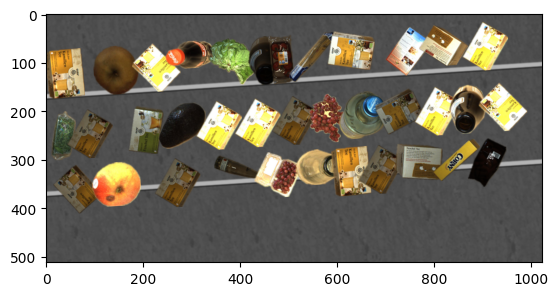

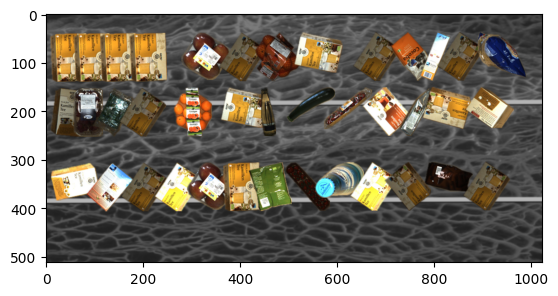

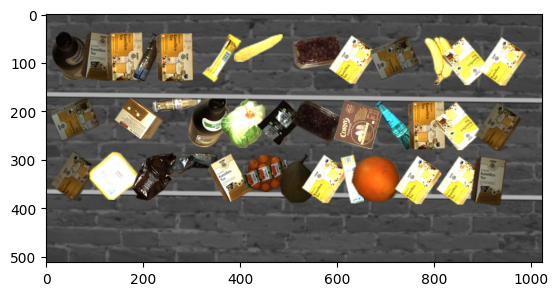

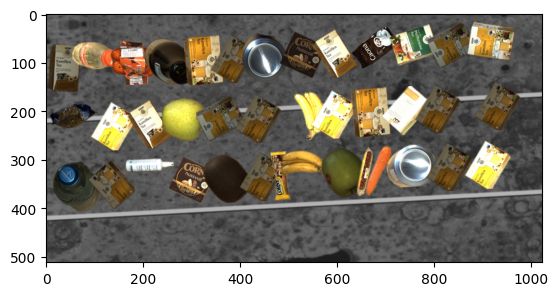

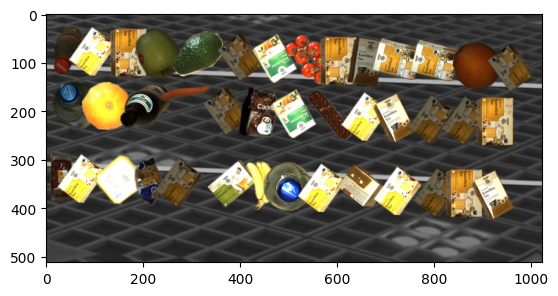

  0%|          | 0/438 [00:06<?, ?it/s]

Done! Processed images saved to: D:\Users\Thomas Work\Desktop\Dataset Processing Practice2\testing_data_expand


In [2]:
# --- CONFIGURATION ---
try:
    from pycocotools.coco import COCO
except ImportError:
    print("Installing pycocotools...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pycocotools"])
    from pycocotools.coco import COCO

IMAGE_DIR = "/d2s_images_v1/images"

ANNOTATION_FILE = "./annotations/D2S_test_10.json"

OUTPUT_DIR = "./testing_data_expand"

IMAGE_RANDOM_DUPLICATES = 5
# ---------------------
def create_masked_dataset():
    batch_id = 0
    print(f"Loading annotations from {ANNOTATION_FILE}...")
    try:
        coco = COCO(ANNOTATION_FILE)
    except Exception as e:
        print(f"CRITICAL ERROR: Could not load COCO object. {e}")
        return

    Path(OUTPUT_DIR).mkdir(exist_ok=True)
    rgb_image_dir = Path(OUTPUT_DIR) / "rgb_images"
    Path(rgb_image_dir).mkdir(exist_ok=True)
    mask_image_dir = Path(OUTPUT_DIR) / "mask_images"
    Path(mask_image_dir).mkdir(exist_ok=True)


    img_ids = coco.getImgIds()
    print(f"Found {len(img_ids)} images. Starting processing...")

    for img_id in tqdm(img_ids):
        img_info = coco.loadImgs(img_id)[0]
        file_name = img_info['file_name']
        img_path = os.path.join(IMAGE_DIR, file_name)

        original_img = cv2.imread(img_path)
        if original_img is None:
            continue

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        for i, ann in enumerate(anns):
            for duplicate_id in range(IMAGE_RANDOM_DUPLICATES):

                # --- PREPARE THE MAIN PRODUCT ---
                # Decode & Fix Mask
                binary_mask = coco.annToMask(ann) * 255
                binary_mask = binary_mask.astype(np.uint8)

                # Crop Main Product
                x, y, w, h = [int(val) for val in ann['bbox']]
                h_img, w_img = original_img.shape[:2]
                y1, y2 = max(0, y), min(h_img, y + h)
                x1, x2 = max(0, x), min(w_img, x + w)

                main_crop = original_img[y1:y2, x1:x2]
                main_mask = binary_mask[y1:y2, x1:x2]

                # Check size valid
                if main_crop.size == 0: continue

                # --- BUILD LIST OF 60 (MAX) ---
                product_queue = []
                current_cat_id = ann['category_id']

                # Add the "Main" item
                product_queue.append((main_crop, main_mask))

                # Add 30 "Same Product" variations
                for _ in range(30):
                    cousin_crop, cousin_mask = preprocess_product_expand.get_random_crop_from_category(coco, current_cat_id, IMAGE_DIR)
                    if cousin_crop is not None:
                        product_queue.append((cousin_crop, cousin_mask))

                # Add 30 "Distractor" items (Different Products)
                for _ in range(30):
                    dist_crop, dist_mask = preprocess_product_expand.get_random_distractor(coco, current_cat_id, IMAGE_DIR)
                    if dist_crop is not None:
                        product_queue.append((dist_crop, dist_mask))

                # Shuffle the list
                shuffle_except_main = product_queue[1:]
                random.shuffle(shuffle_except_main)
                product_queue[1:] = shuffle_except_main

                # Guarantee main product in on shelf
                shuffle_main_guarantee = product_queue[:5]
                random.shuffle(shuffle_main_guarantee)
                product_queue[:5] = shuffle_main_guarantee

                # --- PASTE ON THE SHELF ---
                # Generate clean background
                final_image = preprocess_bg.generate_bg_shelve()
                final_mask = np.zeros(final_image.shape[:2], dtype=np.uint8)

                # Starting Position (Left side of shelf)
                current_x = 10
                y_pos = random.randint(30, 50)
                current_gap = 1
                for p_img, p_mask in product_queue:
                    # Run the Paste Function
                    final_image, final_mask, new_box = preprocess_product_expand.paste_product_to_shelf(
                        final_image, final_mask, p_img, p_mask, current_x, y_pos
                    )

                    # Calculate shift for next product
                    if new_box:
                        # new_box is [x, y, w, h]
                        pasted_width = new_box[2]

                        # Gap Logic:
                        # -30 to 0: Touching/Overlapping (Hard negatives) (90%)
                        # 10 to 30: Small Gap (10%)
                        if random.random() < 0.9:
                            gap = random.randint(-30, -10)
                        else:
                            gap = random.randint(10, 30)

                        current_x += pasted_width + gap

                    # Stop if overlaps canvas
                    if current_gap == 1 and current_x > final_image.shape[1] - 100:
                        current_x = 10
                        y_pos = random.randint(150, 180)
                        current_gap = 2
                    elif current_gap == 2 and current_x > final_image.shape[1] - 100:
                        current_x = 10
                        y_pos = random.randint(280, 310)
                        current_gap = 3
                    elif current_gap == 3 and current_x > final_image.shape[1] - 100:
                        break

                final_image, final_mask = preprocess_bg.apply_camera_roll(final_image, final_mask)

                # --- SAVE ---
                # (Standard saving logic)
                cat_id = ann['category_id']
                cats = coco.loadCats(cat_id)
                cat_name = cats[0]['name'] if cats else "unknown"
                cat_binary_name = f"{cats[0]['name']}_binary" if cats else "unknown"

                save_folder = Path(rgb_image_dir) / cat_name
                save_folder.mkdir(parents=True, exist_ok=True)

                save_binary_folder = Path(mask_image_dir) / cat_binary_name
                save_binary_folder.mkdir(parents=True, exist_ok=True)

                save_filename = f"synthetic_{batch_id:06d}_{duplicate_id}_main.png"
                save_mask_filename = f"synthetic_{batch_id:06d}_{duplicate_id}_mask.png"


                # Save and Debug
                if final_image is not None and final_image.size > 0:
                    cv2.imwrite(str(save_folder / save_filename), final_image)
                    cv2.imwrite(str(save_binary_folder / save_mask_filename), final_mask)

                    # Optional: Show plot only for the first few to save time
                    plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
                    plt.show()
            batch_id += 1
        break # prevent loop for now
    print(f"Done! Processed images saved to: {os.path.abspath(OUTPUT_DIR)}")

if __name__ == "__main__":
    create_masked_dataset()